# 00 — Project map, claims, and evidence

*The full dataset remains outside Git. These notebooks combine synthetic worked examples, aggregate evidence, and small attributed qualitative panels.*

## What I am trying to learn

This project has three deliberately separated learning tracks. The dynamics track
maps **causal vehicle state history → future ego path**. The segmentation track
maps **one front-camera image → overlapping road and lane masks**. The BEV track
maps **a calibrated LiDAR sweep → oriented dynamic-object footprints and temporal
tracks**. Keeping the targets separate prevents an attractive but unsupported
claim that one perception output already improves trajectory prediction.

The scientific hierarchy is:

1. define coordinate, split, and leakage contracts;
2. freeze model families and seeds;
3. select checkpoints and thresholds on validation only;
4. evaluate a sealed test role;
5. bootstrap complete recordings rather than correlated windows.

## End-to-end map and tensor contracts

The three tracks share an experimental method, not a learned feature path.

| Track | Input | Shape | Output | Shape |
|---|---|---:|---|---:|
| Dynamics | normalized state values + validity mask | $B\times21\times9$ each | anchor-local $(x,y)$ future | $B\times30\times2$ |
| Segmentation | RGB front image | $B\times3\times288\times512$ | road/lane logits | $B\times2\times288\times512$ |
| BEV perception | intensity/height/density raster | $B\times3\times608\times608$ | class, center, size, yaw | variable detections |

The history covers $[-2,0]$ s at 10 Hz and the trajectory target covers
$(0,3]$ s. The two segmentation channels are independent because a lane
marking can also be part of the ego-road surface.

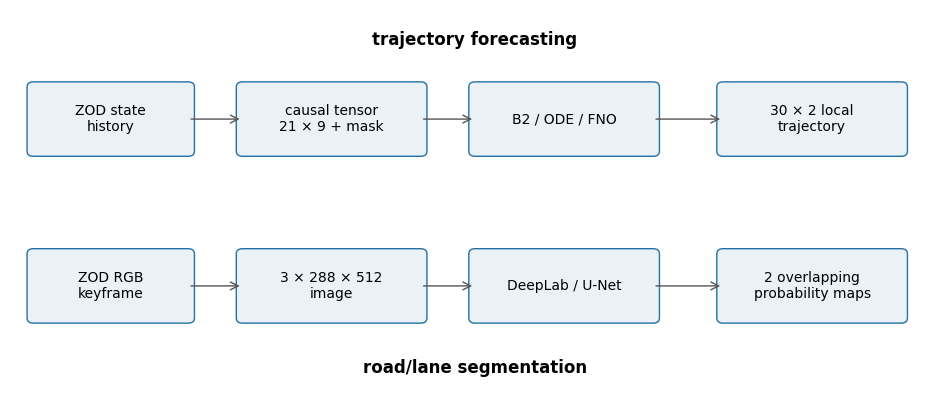

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12); ax.set_ylim(0, 6); ax.axis("off")
boxes = [
    (0.3, 3.8, 2.0, 1.0, "ZOD state\nhistory"),
    (3.0, 3.8, 2.3, 1.0, "causal tensor\n21 × 9 + mask"),
    (6.0, 3.8, 2.3, 1.0, "B2 / ODE / FNO"),
    (9.2, 3.8, 2.3, 1.0, "30 × 2 local\ntrajectory"),
    (0.3, 1.2, 2.0, 1.0, "ZOD RGB\nkeyframe"),
    (3.0, 1.2, 2.3, 1.0, "3 × 288 × 512\nimage"),
    (6.0, 1.2, 2.3, 1.0, "DeepLab / U-Net"),
    (9.2, 1.2, 2.3, 1.0, "2 overlapping\nprobability maps"),
]
for x, y, w, h, label in boxes:
    ax.add_patch(FancyBboxPatch((x,y), w,h, boxstyle="round,pad=.08", fc="#eaf2f8", ec="#2471a3"))
    ax.text(x+w/2, y+h/2, label, ha="center", va="center", fontsize=10)
for y in (4.3, 1.7):
    for x1, x2 in ((2.3,3.0),(5.3,6.0),(8.3,9.2)):
        ax.add_patch(FancyArrowPatch((x1,y),(x2,y),arrowstyle="->",mutation_scale=14,color="#555"))
ax.text(6, 5.45, "trajectory forecasting", ha="center", weight="bold", fontsize=12)
ax.text(6, 0.35, "road/lane segmentation", ha="center", weight="bold", fontsize=12)
plt.show()

In [2]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
plt.style.use("seaborn-v0_8-whitegrid")
summary = json.loads((ROOT / "reports" / "benchmark_summary.json").read_text())

In [3]:
dyn = summary["dynamics"]
seg = summary["segmentation"]
print(f"Dynamics test: {dyn['sample_count']:,} windows / {dyn['recording_group_count']} recordings")
print(f"Segmentation test: {seg['sample_count']} keyframes / {seg['recording_group_count']} recordings")
print("Public evidence status:", summary["status"])

Dynamics test: 2,549 windows / 72 recordings
Segmentation test: 51 keyframes / 51 recordings
Public evidence status: complete


## What the frozen models actually produce

The first panel projects trajectory cases onto their calibrated front-camera
frames. Learned curves average the three frozen seeds, while the camera remains
context rather than model input. The second panel fixes seed 2026 and places
segmentation targets beside all three model outputs. Together they connect the
tensor contracts above to outputs I can inspect.

![Held-out camera trajectories](../reports/figures/dynamics_camera_predictions.png)

![Held-out segmentation outputs](../reports/figures/segmentation_model_comparison.png)

## Read a result as a claim with boundaries

“Temporal FNO is best” is too vague. The defensible version is:

> On the frozen 2,549-window ZOD test role, temporal FNO has the lowest
> three-seed mean ADE (0.542 m). Its paired ADE improvement over B2 is −0.131 m,
> and a 95% recording-level bootstrap interval excludes zero.

That sentence states the dataset role, metric, seed reduction, comparison, and
uncertainty unit. It does **not** claim safety, closed-loop performance, or
superiority under every distribution shift.

## Metrics in equations

For sample $i$, horizon step $t$, target $y_{i,t}$, and prediction
$\hat y_{i,t}$,

\[
\operatorname{ADE}_i=\frac{1}{T}\sum_{t=1}^{T}
\lVert\hat y_{i,t}-y_{i,t}\rVert_2,
\qquad
\operatorname{FDE}_i=\lVert\hat y_{i,T}-y_{i,T}\rVert_2.
\]

The miss indicator is $\mathbb 1[\operatorname{FDE}_i>2\text{ m}]$. For
segmentation channel $c$, strict intersection-over-union is

\[
\operatorname{IoU}_c=\frac{TP_c}{TP_c+FP_c+FN_c}.
\]

The selection score is
$S=\tfrac12(\operatorname{IoU}_{road}+F1^{tol}_{lane})$. These definitions
matter because a ranking is only meaningful after the metric is fixed.

In [4]:
rows = []
for name, entry in dyn["models"].items():
    rows.append({
        "model": name,
        "ADE_m": entry["metrics_across_seeds"]["ade_m"]["mean"],
        "FDE_m": entry["metrics_across_seeds"]["fde_m"]["mean"],
        "latency_ms": entry["latency"]["batch_1_median_ms"],
        "parameters": entry["parameters"],
    })
pd.DataFrame(rows).sort_values("ADE_m").round(4)

,model,ADE_m,FDE_m,latency_ms,parameters
3,temporal_fno,0.5424,1.4864,2.5837,1230242
2,neural_ode,0.5435,1.5007,24.1673,108162
1,hybrid_neural_ode,0.5507,1.5245,35.7466,108674
0,b2_state_mlp,0.6732,1.7082,0.2013,112444


In [5]:
rows = []
for name, entry in seg["models"].items():
    metrics = entry["global_pixel_metrics_across_seeds"]
    rows.append({
        "model": name,
        "road_IoU": metrics["road_iou"]["mean"],
        "lane_IoU": metrics["lane_iou"]["mean"],
        "lane_tolerant_F1": metrics["lane_tolerant_f1"]["mean"],
        "score": metrics["selection_score"]["mean"],
        "parameters_M": entry["parameters"] / 1e6,
    })
pd.DataFrame(rows).sort_values("score", ascending=False).round(4)

,model,road_IoU,lane_IoU,lane_tolerant_F1,score,parameters_M
1,resnet18_fourier_unet,0.8564,0.4892,0.8651,0.8608,56.8447
2,resnet18_unet,0.8579,0.4663,0.8609,0.8594,14.3743
0,deeplabv3_mobilenet_v3_large,0.8087,0.1871,0.6542,0.7314,11.0206


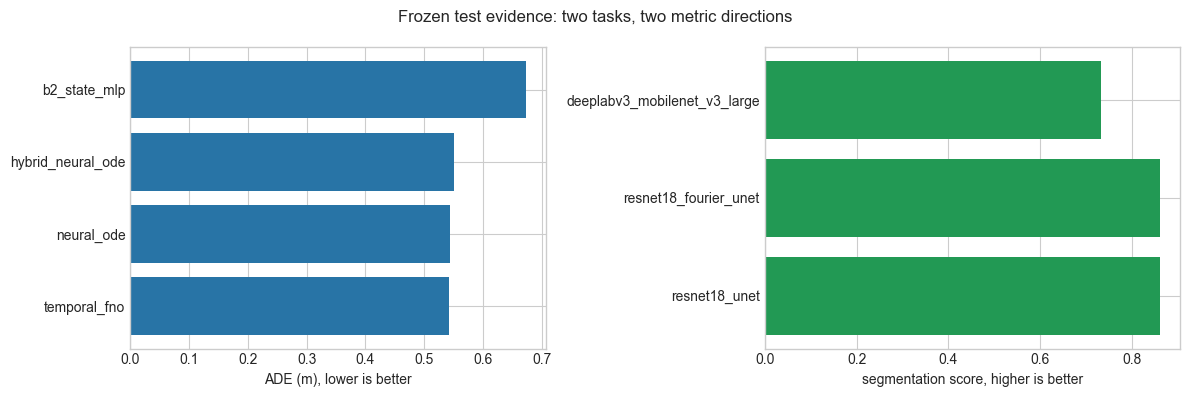

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
dyn_frame = pd.DataFrame([
    (name, entry["metrics_across_seeds"]["ade_m"]["mean"])
    for name, entry in dyn["models"].items()
], columns=["model", "ADE"])
seg_frame = pd.DataFrame([
    (name, entry["global_pixel_metrics_across_seeds"]["selection_score"]["mean"])
    for name, entry in seg["models"].items()
], columns=["model", "score"])
ax[0].barh(dyn_frame.model, dyn_frame.ADE, color="#2874a6")
ax[0].invert_yaxis(); ax[0].set_xlabel("ADE (m), lower is better")
ax[1].barh(seg_frame.model, seg_frame.score, color="#229954")
ax[1].invert_yaxis(); ax[1].set_xlabel("segmentation score, higher is better")
fig.suptitle("Frozen test evidence: two tasks, two metric directions")
plt.tight_layout(); plt.show()

## Evidence integrity

The JSON reports include checkpoint hashes and cache hashes. Hashes do not prove
that a model is good; they prove that the exact evaluated artifact is identifiable.
This matters when nine training runs share names and directory structures.

In [7]:
import hashlib
for filename in ("v4_dynamics_test.json", "v4_segmentation_test.json"):
    payload = (ROOT / "reports" / filename).read_bytes()
    print(filename, hashlib.sha256(payload).hexdigest()[:20] + "…")

v4_dynamics_test.json 6b98afcf6253a2e9c2df…
v4_segmentation_test.json 197c71ab550ff943712f…


## Takeaways

- The strongest trajectory claim is the **paired improvement over B2**, not the
  tiny FNO–NeuralODE ranking.
- The strongest segmentation claim is the **U-Net family improvement over
  DeepLab**, not the Fourier–ordinary U-Net ranking.
- Model promotion includes latency and parameter cost.
- Negative complexity findings are useful when they change the final decision.

### Check my understanding

1. Why would averaging predictions across seeds be a different estimator from
   averaging each seed's ADE?  
2. Which test examples may influence threshold choice?  
3. Why can the three tracks be presented in one project without claiming an
   end-to-end driving system?

Answers: ensembling changes predictions before a nonlinear metric; no test
example may select a threshold; and the tracks share data discipline and an
autonomous-driving setting but remain experimentally independent.